# Создание кастомного MOONDATASET

>### Требования к архитектуре U-Net:
>- Глубина: 4 уровня down/4 up (энкодер-декодер с skip-связями).
>- Базовые каналы на первом уровне: 32 или 64 (по желанию можно выбрать свое количество каналов, но надо будет объяснить).
>- Даунсемплинг: stride 2 или MaxPool.
>- Итоговый слой: 1 канал с сигмоидой (бинарная сегментация).
>- Ограничение на количество параметров: до ~2.5M (рекомендуется укладываться, но допускается ±10%).
>- Вход: 128×128×3.

In [1]:
import os
import random
from PIL import Image
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
from typing import List, Tuple

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
root = "tiny-imagenet-200"

In [2]:
class MoonSegmentationDataset(Dataset):

    def __init__(self, root_dir, image_folder='render', mask_folder='ground', 
                 image_ids=None, augmentation=None, preprocessing=None):
        self.root_dir = root_dir
        self.image_folder = image_folder
        self.mask_folder = mask_folder
        self.augmentation = augmentation
        self.preprocessing = preprocessing
        
        images_dir = os.path.join(root_dir, 'images', image_folder)
        masks_dir = os.path.join(root_dir, 'images', mask_folder)
        
        if image_ids is None:
            all_images = os.listdir(images_dir)
            self.image_ids = [img.replace('.png', '') for img in all_images if img.endswith('.png')]
        else:
            self.image_ids = image_ids
        
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        
        image_path = os.path.join(self.root_dir, 'images', self.image_folder, f"{image_id}.png")
        
        # Для масок убираем префикс "render" если он есть
        # Например: render0001 - 0001
        mask_id = image_id.replace('render', '') if 'render' in image_id else image_id
        mask_path = os.path.join(self.root_dir, 'images', self.mask_folder, f"ground{mask_id}.png")
        
        image = cv2.imread(image_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Так как используем opencv, то не забываем преводить из BGR в RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Нормализуем бинарную маску к [0, 1]
        # 0 = фон, 1 = камни
        mask = (mask > 0).astype(np.float32)
        
        # Применяем аугментации
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        
        # Применяем предобработку
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        
        return image, mask


Аугментрование

In [3]:
# Аугментации для обучения
train_augmentation = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=45, p=0.5),
    A.OneOf([
        A.GaussNoise(var_limit=(10.0, 50.0)),
        A.GaussianBlur(blur_limit=(3, 7)),
        A.MedianBlur(blur_limit=5),
    ], p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
])

preprocessing = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_augmentation = A.Compose([
    A.Resize(256, 256),
])

c:\Users\Stasy\Desktop\ucheba\AI_Architecture\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\Stasy\AppData\Local\Temp\ipykernel_14084\2297332127.py:9: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0)),


Разделение на train/val

In [4]:
# Путь к данным
DATA_ROOT = "MOON_SEGMENTATION_BINARY/"

images_dir = os.path.join(DATA_ROOT, 'images', 'render')
all_images = [img.replace('.png', '') for img in os.listdir(images_dir) if img.endswith('.png')][:100]

print(f"Всего изображений: {len(all_images)}")

train_ids, val_ids = train_test_split(all_images, test_size=0.2, random_state=42)

print(f"Train: {len(train_ids)} изображений")
print(f"Val: {len(val_ids)} изображений")

train_dataset = MoonSegmentationDataset(
    root_dir=DATA_ROOT,
    image_folder='render',
    mask_folder='ground',
    image_ids=train_ids,
    augmentation=train_augmentation,
    preprocessing=preprocessing
)

val_dataset = MoonSegmentationDataset(
    root_dir=DATA_ROOT,
    image_folder='render',
    mask_folder='ground',
    image_ids=val_ids,
    augmentation=val_augmentation,
    preprocessing=preprocessing
)

BATCH_SIZE = 4
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Батчей в train: {len(train_loader)}")
print(f"Батчей в val: {len(val_loader)}")


Всего изображений: 100
Train: 80 изображений
Val: 20 изображений
Батчей в train: 20
Батчей в val: 5


Размер батча изображений: torch.Size([4, 3, 256, 256])
Размер батча масок: torch.Size([4, 256, 256])


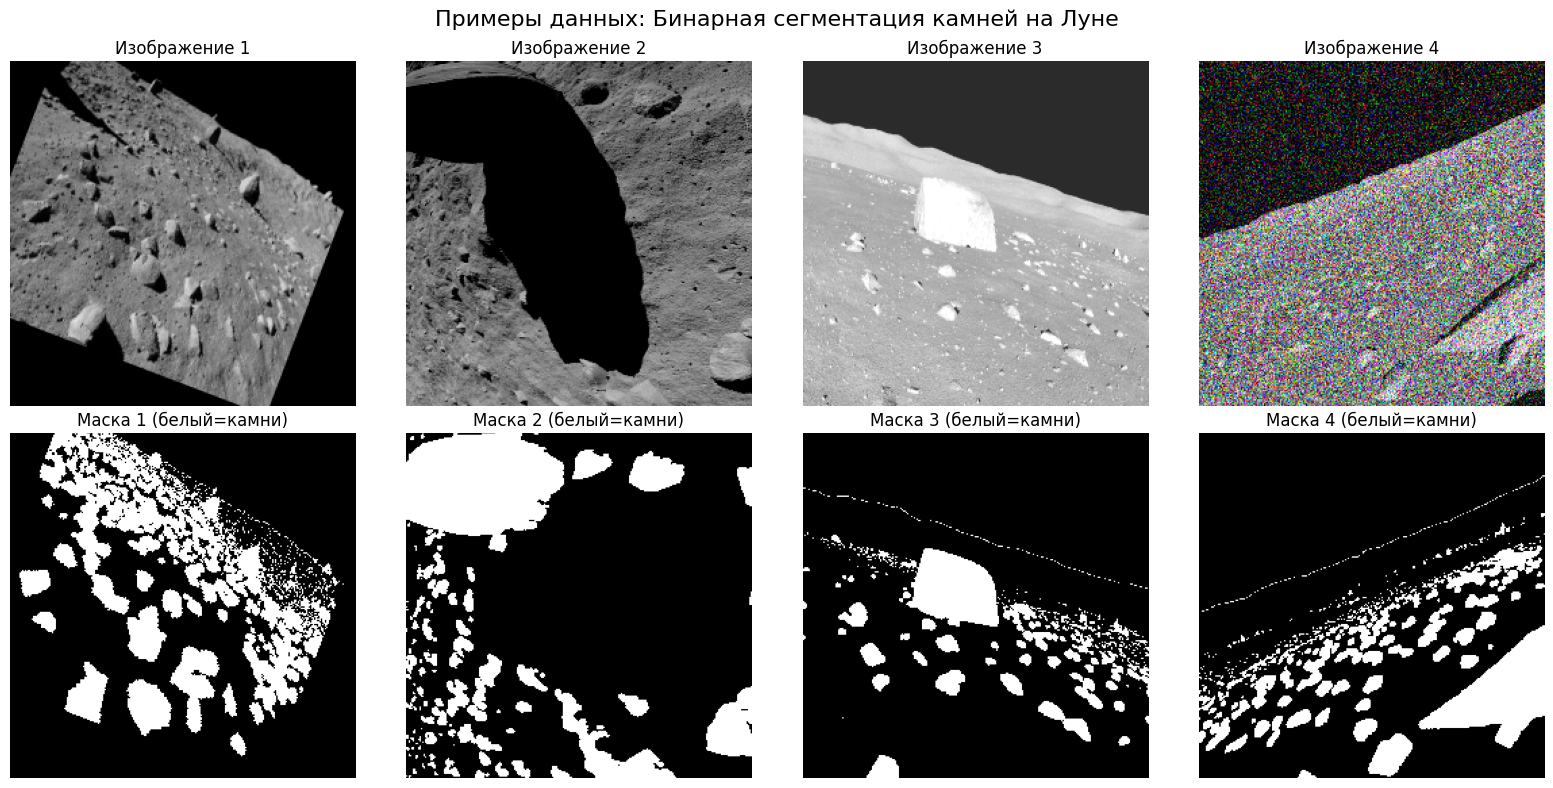

In [5]:
def denormalize(img_tensor):
    """Денормализация изображения для визуализации"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1)

images, masks = next(iter(train_loader))

print(f"Размер батча изображений: {images.shape}")
print(f"Размер батча масок: {masks.shape}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(min(4, len(images))):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    mask = masks[i].numpy()
    
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Изображение {i+1}")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title(f"Маска {i+1} (белый=камни)")
    axes[1, i].axis('off')

plt.suptitle("Примеры данных: Бинарная сегментация камней на Луне", fontsize=16)
plt.tight_layout()
plt.show()


## Полная кастомная U-Net архитектура

In [39]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.double_conv(x)



In [41]:

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[32, 64, 128, 256]):
        super(UNet, self).__init__()
        
        self.encoder_blocks = nn.ModuleList()
        self.decoder_blocks = nn.ModuleList()
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        prev_channels = in_channels
        for feature in features:
            self.encoder_blocks.append(DoubleConv(prev_channels, feature))
            prev_channels = feature

        self.bottleneck = DoubleConv(features[-1], features[-1])

        # Декодер
        for feature in reversed(features[:-1]):  # Исключаем последний уровень (чтобы уменьшить параметры)
            self.decoder_blocks.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.decoder_blocks.append(
                DoubleConv(feature * 2, feature)
            )

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
        
        total_params = sum(p.numel() for p in self.parameters())
        print(f"Параметров: {total_params:,}")
        print(f"Уровней encoder: {len(features)}")
        print(f"Конфигурация каналов: {features}")
    
    def forward(self, x):
        skip_connections = []

        # Проход через энкодер
        for encoder_block in self.encoder_blocks:
            x = encoder_block(x)
            skip_connections.append(x)
            x = self.pool(x)
        
        x = self.bottleneck(x)
        
        skip_connections = skip_connections[::-1]

        # Декодер с правильным количеством каналов
        for idx in range(0, len(self.decoder_blocks), 2):
            x = self.decoder_blocks[idx](x)
            
            skip_connection = skip_connections[idx // 2]
            
            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:], 
                                mode='bilinear', align_corners=True)
            
            x = torch.cat([skip_connection, x], dim=1)
            
            x = self.decoder_blocks[idx + 1](x)

        output = self.final_conv(x)
        
        return output

# Пример запуска
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=3, out_channels=1, features=[32, 64, 128, 256]).to(device)

test_input = torch.randn(1, 3, 256, 256).to(device)
test_output = model(test_input)

print(f"   Вход:  {test_input.shape}")
print(f"   Выход: {test_output.shape}")


Параметров: 3,109,601
Уровней encoder: 4
Конфигурация каналов: [32, 64, 128, 256]


RuntimeError: Given groups=1, weight of size [128, 256, 3, 3], expected input[1, 384, 32, 32] to have 256 channels, but got 384 channels instead

In [33]:
import torch.optim as optim
from torch.utils.data import DataLoader
import torch
import numpy as np

def iou_score(y_true, y_pred):
    intersection = torch.sum(y_true * y_pred)
    union = torch.sum(y_true) + torch.sum(y_pred) - intersection
    return intersection / (union + 1e-6)

def dice_score(y_true, y_pred):
    intersection = torch.sum(y_true * y_pred)
    return (2. * intersection) / (torch.sum(y_true) + torch.sum(y_pred) + 1e-6)

def pixel_accuracy(y_true, y_pred):
    correct = torch.sum(y_true == y_pred)
    total = torch.numel(y_true)
    return correct / total

def train_and_evaluate(model, train_loader, val_loader, device, epochs=10, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.BCEWithLogitsLoss()

    train_losses, val_losses = [], []
    val_iou, val_dice, val_accuracy = [], [], []

    for epoch in range(epochs):
        model.train()
        train_loss, correct_train, total_train = 0.0, 0, 0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs.squeeze(1), masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct_train += torch.sum(preds == masks).item()
            total_train += torch.numel(masks)

        train_loss /= len(train_loader)
        train_accuracy = correct_train / total_train
        train_losses.append(train_loss)

        model.eval()
        val_loss, val_iou_epoch, val_dice_epoch, val_accuracy_epoch = 0.0, 0.0, 0.0, 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs.squeeze(1), masks)
                val_loss += loss.item()

                preds = (torch.sigmoid(outputs) > 0.5).float()
                val_iou_epoch += iou_score(masks, preds).item()
                val_dice_epoch += dice_score(masks, preds).item()
                val_accuracy_epoch += pixel_accuracy(masks, preds).item()

        val_loss /= len(val_loader)
        val_iou_epoch /= len(val_loader)
        val_dice_epoch /= len(val_loader)
        val_accuracy_epoch /= len(val_loader)

        val_losses.append(val_loss)
        val_iou.append(val_iou_epoch)
        val_dice.append(val_dice_epoch)
        val_accuracy.append(val_accuracy_epoch)

        print(f"Epoch [{epoch+1}/{epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, "
              f"Val Loss: {val_loss:.4f}, IoU: {val_iou_epoch:.4f}, "
              f"Dice: {val_dice_epoch:.4f}, Pixel Accuracy: {val_accuracy_epoch:.4f}")

    return model, train_losses, val_losses, val_iou, val_dice, val_accuracy


In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=3, out_channels=1, features=[32, 64, 128, 256]).to(device)

# Обучение и тестирование модели
trained_model, train_losses, val_losses, val_iou, val_dice, val_accuracy = train_and_evaluate(
    model, 
    train_loader, 
    val_loader, 
    device,
    epochs=10,
    lr=1e-3
)


Параметров: 3,118,673
Уровней encoder: 4
Конфигурация каналов: [32, 64, 128, 256]


RuntimeError: Given groups=1, weight of size [128, 256, 3, 3], expected input[4, 384, 32, 32] to have 256 channels, but got 384 channels instead

Визуализация результата

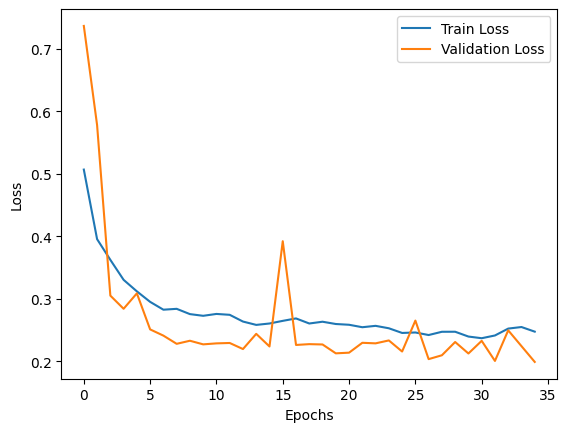

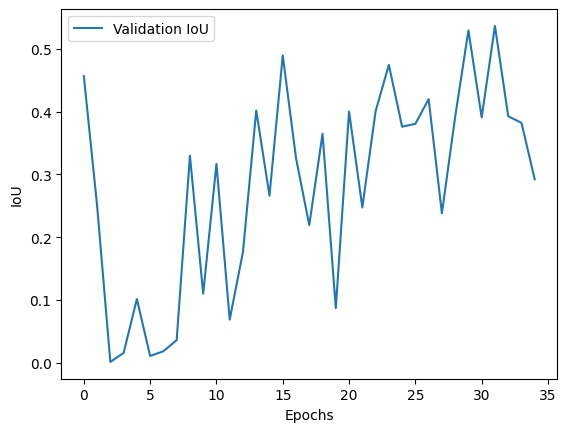

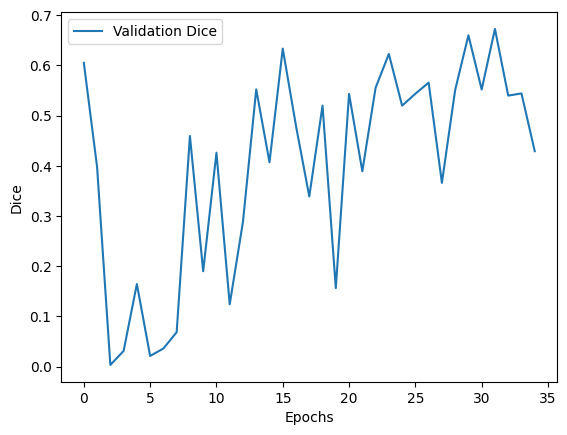

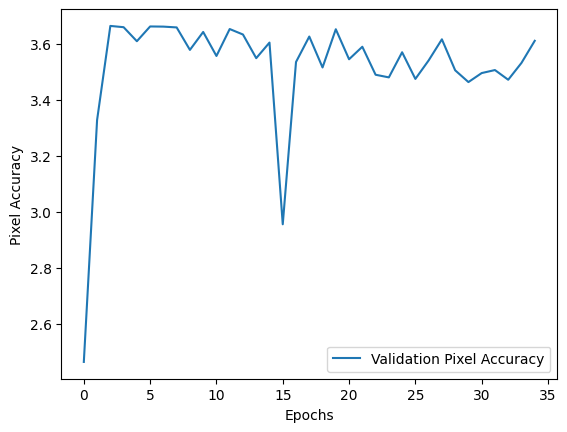

In [28]:
import matplotlib.pyplot as plt

# График потерь
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# График IoU
plt.plot(val_iou, label='Validation IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend()
plt.show()

# График Dice
plt.plot(val_dice, label='Validation Dice')
plt.xlabel('Epochs')
plt.ylabel('Dice')
plt.legend()
plt.show()

# График Pixel Accuracy
plt.plot(val_accuracy, label='Validation Pixel Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Pixel Accuracy')
plt.legend()
plt.show()
